Report Idea:

Describe macro data, etf data, why we xhose the particular etfs

Start from Q-learning. Recognize Q-learning cannot solve continuous weight allocation. Proceed to PPO and explain why it can solve continuous weight allocation, but it is built on Q-learning's intuition. How do we pick V(s), how does it connect to neural network (to what we learned), how do we pick the parameters (e.g. how many layers should we pick).

Problems we can face: If you update too aggressively: probabilities explode; policy becomes unstable; performance collapses. In finance terms: The model sees one lucky month → suddenly allocates 90% to Energy forever. Need to restrict learning rate.

Lead us to PPO-clipping to add a hard constraint on policy update size.

Logic should be clearly explained: Reward → Return → Advantage → Objective → Parameter Update: 

We first define a reward function reflecting portfolio performance.
As the agent interacts with the environment, rewards are accumulated into returns.
The critic estimates a baseline value function, allowing computation of the advantage, which measures how much better or worse an action performed relative to expectation.
These advantage estimates enter the PPO surrogate objective, which determines how the policy distribution is adjusted.
The objective is then optimized via gradient ascent to update the parameters of the action distribution.

Talk about we got the idea from this github: https://github.com/tsmatz/reinforcement-learning-tutorials/blob/a8506d6e7f4bf6b3ad200e87dfb5d0ee62dc76d5/04-ppo.ipynb

But clearly the dataset is different: 
1. The CartPole example is:

- 4-dimensional state

- 2 discrete actions

- reward from environment

- episode ends automatically

2. Our project is:

- High-dimensional state (ETF + macro)

- Continuous action (portfolio weights)

- Reward = portfolio return

- No natural “episode end” except sample end

So we must redesign the environment properly.

1. Step 1: Dataset preparation. Besides usual descriptions, state our states: 
At time t, state will include:

- Sector ETF features (momentum, vol, dispersion, etc.)

- Macro features (rates, inflation, etc.)

- Possibly previous weights

Conclusion: Does the RL perform better than some naive baseline model?

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")



## Step 1: Load data + clean data + set index

In [22]:
macro_df = pd.read_csv("macro_data.csv")
macro_df["Unnamed: 0"] = pd.to_datetime(macro_df["Unnamed: 0"])
macro_df = macro_df.set_index("Unnamed: 0").sort_index()
macro_df.index.name = "date"
display(macro_df)

,CPI,INDPRO,TERM_SPREAD,FED_RATE,HY_OAS,VIX,CPI_q,INDPRO_q,TERM_SPREAD_m,FED_RATE_m,...,VIX_z,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
date,,,,,,,,,,,,,,,,,,,,,
2016-12-31,242.637000,99.0214,1.970000,0.54,4.620000,14.070000,0.006058,0.002792,0.331081,0.317073,...,-0.481474,0.645725,1.189782,2.795910,1.038643,-1.018538,-1.016227,0,0,0
2017-01-31,243.618000,98.7611,1.962516,0.65,4.633392,13.980987,0.007765,0.000000,-0.003799,0.203704,...,-0.498953,0.993252,0.790520,-0.053161,0.489363,0.016223,-0.124984,0,0,0
2017-02-28,244.006000,98.3646,1.970000,0.66,3.950000,11.810000,0.008181,0.000158,0.003814,0.015385,...,-0.960364,1.078891,0.743678,0.013558,-0.349651,-1.582065,-0.655788,0,0,0
2017-03-31,243.892000,99.0137,1.830000,0.79,3.570000,12.540000,0.005172,-0.000078,-0.071066,0.196970,...,-0.770080,0.206501,0.648779,-0.590274,0.420665,-0.950084,0.146048,0,0,0
2017-04-30,244.193000,100.0224,1.821906,0.90,3.559316,12.443833,0.002360,0.012771,-0.004423,0.139241,...,-0.757298,-0.542625,2.218795,-0.087853,0.155158,0.064685,-0.103543,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,323.364000,101.5867,-0.120000,4.33,3.130000,20.380000,0.008684,0.006153,-0.142857,0.000000,...,0.631240,0.599187,0.623189,-0.311262,0.486852,0.861948,1.075844,1,0,0
2025-09-30,324.368000,101.7779,-0.129730,4.22,2.840000,16.120000,0.008921,0.002950,0.081087,-0.025404,...,-0.432450,0.728875,0.249218,0.267590,-0.900274,-0.899257,-1.324695,1,0,0
2025-10-31,324.330696,101.5163,0.110000,4.09,2.810000,16.290000,0.006825,-0.003707,-1.847912,-0.030806,...,-0.435077,0.028106,-0.630003,-3.314174,-1.109091,-0.023841,-0.072496,0,0,0


In [23]:
etf_df = pd.read_parquet("sector_panel.parquet")  # MultiIndex (date, ticker)
etf_df.head(30)

ret_1m    vol_1m     amihud_1m  avg_corr_1m  xsec_disp_1m
date       ticker                                                             
2016-01-31 BIL     0.000219  0.000225  3.220861e-12     0.750529      0.046963
           VOX     0.012276  0.016287  2.306592e-09     0.750529      0.046963
           XLB    -0.107094  0.017291  4.828052e-11     0.750529      0.046963
           XLE    -0.034980  0.029289  2.081823e-11     0.750529      0.046963
           XLF    -0.088544  0.016266  1.079141e-11     0.750529      0.046963
           XLI    -0.056970  0.014622  1.882635e-11     0.750529      0.046963
           XLK    -0.037124  0.018166  2.528782e-11     0.750529      0.046963
           XLP     0.005348  0.011606  1.625692e-11     0.750529      0.046963
           XLRE   -0.063943  0.014778  7.212851e-07     0.750529      0.046963
           XLU     0.049445  0.010942  1.656133e-11     0.750529      0.046963
           XLV    -0.077190  0.015242  1.347519e-11     0.750529      0.046963
           XLY    -0.051817  0.014947  1.762328e-11     0.750529      0.046963
2016-02-29 BIL     0.000000  0.000201  3.031380e-12     0.572733      0.031915
           VOX     0.039675  0.009659  9.507144e-10     0.572733      0.031915
           XLB     0.078153  0.018255  5.532553e-11     0.572733      0.031915
           XLE    -0.028002  0.020424  1.531520e-11     0.572733      0.031915
           XLF    -0.029005  0.017458  9.986258e-12     0.572733      0.031915
           XLI     0.042609  0.012843  1.637927e-11     0.572733      0.031915
           XLK    -0.006547  0.012570  2.193987e-11     0.572733      0.031915
           XLP     0.003152  0.007772  1.070283e-11     0.572733      0.031915
           XLRE    0.004796  0.018519  1.124784e-06     0.572733      0.031915
           XLU     0.019375  0.010274  1.081675e-11     0.572733      0.031915
           XLV    -0.003611  0.011823  1.386202e-11     0.572733      0.031915
           XLY     0.004453  0.014298  1.754939e-11     0.572733      0.031915
2016-03-31 BIL     0.000000  0.000151  2.866007e-12     0.449260      0.023150
           VOX     0.055728  0.007755  5.110872e-10     0.449260      0.023150
           XLB     0.075731  0.010764  3.899624e-11     0.449260      0.023150
           XLE     0.101659  0.016241  1.271842e-11     0.449260      0.023150
           XLF     0.071591  0.010760  6.835451e-12     0.449260      0.023150
           XLI     0.069735  0.008184  1.167406e-11     0.449260      0.023150

In [24]:
panel = etf_df.join(macro_df, how="left")

# sanity check of joining the two dfs
print(panel.index.get_level_values(0).min(), panel.index.get_level_values(0).max())
print(macro_df.index.min(), macro_df.index.max())

# Check missing macro rows after join
missing = panel[macro_df.columns].isna().any(axis=1).groupby(level=0).any()
print("Missing macro dates:", missing[missing].index)

# restrict to the intersection of dates
common_dates = etf_df.index.get_level_values(0).unique().intersection(macro_df.index)
panel = etf_df.loc[common_dates].join(macro_df, how="left")

# confirm no missing now
missing = panel[macro_df.columns].isna().any(axis=1).groupby(level=0).any()
print("Missing macro dates after restriction:", missing[missing].index)
print("Panel date range:", panel.index.get_level_values(0).min(), panel.index.get_level_values(0).max())

# extract date from multi-index
dates = sorted(panel.index.get_level_values(0).unique())



2016-01-31 00:00:00 2026-01-31 00:00:00
2016-12-31 00:00:00 2025-12-31 00:00:00
Missing macro dates: DatetimeIndex(['2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2026-01-31'],
              dtype='datetime64[ms]', name='date', freq=None)
Missing macro dates after restriction: DatetimeIndex([], dtype='datetime64[ms]', name='date', freq=None)
Panel date range: 2016-12-31 00:00:00 2025-12-31 00:00:00


# Note, maybe flatten this dataframe: panel

In [25]:
panel

ret_1m    vol_1m     amihud_1m  avg_corr_1m  \
date       ticker                                                  
2016-12-31 BIL     0.000219  0.000215  7.843006e-12     0.454200   
           VOX     0.074492  0.007974  6.466338e-10     0.454200   
           XLB     0.001766  0.006030  2.029713e-11     0.454200   
           XLE     0.017308  0.006926  7.542330e-12     0.454200   
           XLF     0.037564  0.008678  5.144601e-12     0.454200   
...                     ...       ...           ...          ...   
2025-12-31 XLP    -0.013441  0.004916  5.063698e-12     0.311498   
           XLRE   -0.021095  0.005576  1.701068e-11     0.311498   
           XLU    -0.050870  0.007966  8.442068e-12     0.311498   
           XLV    -0.013897  0.008170  4.262366e-12     0.311498   
           XLY     0.011982  0.007903  7.268462e-12     0.311498   

                   xsec_disp_1m      CPI    INDPRO  TERM_SPREAD  FED_RATE  \
date       ticker                                                           
2016-12-31 BIL         0.023549  242.637   99.0214         1.97      0.54   
           VOX         0.023549  242.637   99.0214         1.97      0.54   
           XLB         0.023549  242.637   99.0214         1.97      0.54   
           XLE         0.023549  242.637   99.0214         1.97      0.54   
           XLF         0.023549  242.637   99.0214         1.97      0.54   
...                         ...      ...       ...          ...       ...   
2025-12-31 XLP         0.023149  326.030  102.3250         0.28      3.72   
           XLRE        0.023149  326.030  102.3250         0.28      3.72   
           XLU         0.023149  326.030  102.3250         0.28      3.72   
           XLV         0.023149  326.030  102.3250         0.28      3.72   
           XLY         0.023149  326.030  102.3250         0.28      3.72   

                   HY_OAS  ...     VIX_z   CPI_q_z  INDPRO_q_z  \
date       ticker          ...                                   
2016-12-31 BIL       4.62  ... -0.481474  0.645725    1.189782   
           VOX       4.62  ... -0.481474  0.645725    1.189782   
           XLB       4.62  ... -0.481474  0.645725    1.189782   
           XLE       4.62  ... -0.481474  0.645725    1.189782   
           XLF       4.62  ... -0.481474  0.645725    1.189782   
...                   ...  ...       ...       ...         ...   
2025-12-31 XLP       2.94  ... -0.246812 -0.590004    0.496854   
           XLRE      2.94  ... -0.246812 -0.590004    0.496854   
           XLU       2.94  ... -0.246812 -0.590004    0.496854   
           XLV       2.94  ... -0.246812 -0.590004    0.496854   
           XLY       2.94  ... -0.246812 -0.590004    0.496854   

                   TERM_SPREAD_m_z  FED_RATE_m_z  HY_OAS_m_z   VIX_m_z  \
date       ticker                                                        
2016-12-31 BIL            2.795910      1.038643   -1.018538 -1.016227   
           VOX            2.795910      1.038643   -1.018538 -1.016227   
           XLB            2.795910      1.038643   -1.018538 -1.016227   
           XLE            2.795910      1.038643   -1.018538 -1.016227   
           XLF            2.795910      1.038643   -1.018538 -1.016227   
...                            ...           ...         ...       ...   
2025-12-31 XLP            2.859498     -1.310559    0.566022  0.215282   
           XLRE           2.859498     -1.310559    0.566022  0.215282   
           XLU            2.859498     -1.310559    0.566022  0.215282   
           XLV            2.859498     -1.310559    0.566022  0.215282   
           XLY            2.859498     -1.310559    0.566022  0.215282   

                   curve_inv  high_vol  credit_spread  
date       ticker                                      
2016-12-31 BIL             0         0              0  
           VOX             0         0              0  
           XLB             0         0              0  
           XLE             0    

## Step 2: Set up portfolio environment for implementing PPO: define the simulated financial world that the RL agent will interact with  
Each time step represent 1 month.

1. State

At month t (month-end), the agent sees:

- ETF features (ret, vol, illiquidity)

- Cross-sectional regime measures (avg_corr, dispersion)

- Macro features (z-scored CPI, VIX, etc.)

- Previous portfolio weights

2. Action

At each month $t$, the agent chooses portfolio weights:

$$
w_t = (w_{BIL}, w_{VOX}, \dots, w_{XLY})
$$

Constraints:

- Long-only: $w_i \ge 0$
- Fully invested: $\sum_i w_i = 1$
- BIL (cash asset) is included in the allocation universe

3. Reward

After choosing weights at time $t$, the next month’s returns realize.

First compute gross portfolio return:

$$
R^{gross}_{t+1} = w_t^\top R_{t+1}
$$

Turnover is defined as:

$$
\text{turnover}_t = \sum_i |w_{i,t} - w_{i,t-1}|
$$

Transaction cost is parameterized in basis points:

$$
\text{tc} = \frac{\text{tc\_bps}}{10000}
$$

Net return:

$$
R^{net}_{t+1} = R^{gross}_{t+1} - \text{tc} \cdot \text{turnover}_t
$$

Final reward:

$$
r_{t+1}
=
\log\big(1 + R^{net}_{t+1}\big)
-
\gamma \|w_t\|_2^2
$$

Where:

- $\text{tc\_bps}$ controls transaction cost intensity  
- $\gamma$ controls the L2 concentration penalty  

4. Episode

One full training episode consists of:

- Start: December 2016  
- Step forward month-by-month  
- End: December 2022 (for `train_env`)  

Each episode represents one complete historical backtest path.


In [26]:
TICKERS = ["BIL","VOX","XLB","XLE","XLF","XLI","XLK","XLP","XLRE","XLU","XLV","XLY"]

asset_cols  = ["ret_1m","vol_1m","amihud_1m"]
shared_cols = ["avg_corr_1m","xsec_disp_1m"]

# keep macro small + normalized first at this stage, better for neural network training
macro_cols = [
    "CPI_q_z","INDPRO_q_z","TERM_SPREAD_m_z","FED_RATE_m_z","HY_OAS_m_z","VIX_m_z",
    "curve_inv","high_vol","credit_spread"
]

# Set Monthly portfolio environment
# This section is checked by AI
class PortfolioEnv:
    def __init__(self, panel, tickers, asset_cols, shared_cols, macro_cols,
                 tc_bps=10.0, l2_gamma=0.01, start_date=None, end_date=None):
        self.panel = panel
        self.tickers = list(tickers)
        self.asset_cols = list(asset_cols)
        self.shared_cols = list(shared_cols)
        self.macro_cols = list(macro_cols)
        self.l2_gamma = float(l2_gamma)

        # Transaction costs
        self.tc_bps = float(tc_bps)          
        self.tc = self.tc_bps / 10000.0      
        
        # inside __init__
        #this is teh risk free asset index for the BIL residual scheme
        self.bil_idx = self.tickers.index("BIL")   # or TICKERS / self.asset_names, etc.


        all_dates = sorted(panel.index.get_level_values(0).unique())
        if start_date is not None:
            all_dates = [d for d in all_dates if d >= pd.to_datetime(start_date)]
        if end_date is not None:
            all_dates = [d for d in all_dates if d <= pd.to_datetime(end_date)]

        if len(all_dates) < 2:
            raise ValueError("Need at least 2 dates (t and t+1) in the env range.")

        self.dates = all_dates
        self.n_assets = len(self.tickers)

        self.reset()

    def _slice(self, date):
        # enforce consistent ticker ordering
        return self.panel.loc[date].reindex(self.tickers)

    def _get_state(self, date):
        df = self._slice(date)

        asset_block = df[self.asset_cols].to_numpy(np.float32).reshape(-1)  # N*len(asset_cols)
        shared = df[self.shared_cols].iloc[0].to_numpy(np.float32)          # len(shared_cols)
        macro  = df[self.macro_cols].iloc[0].to_numpy(np.float32)           # len(macro_cols)

        # include previous weights to help control turnover
        state = np.concatenate([asset_block, shared, macro, self.w_prev], axis=0).astype(np.float32)
        return state

    def reset(self):
        self.t = 0
        self.done = False
        self.w_prev = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        return self._get_state(self.dates[self.t])

    #use this if you want to forbid shorting
    def _action_to_weights(self, a, eps=1e-8):
        a = np.asarray(a, dtype=np.float32)
        a = np.clip(a, -20, 20)               # numerical safety (optional)
        a = a - a.max()                       # stable softmax
        w = np.exp(a)
        w = w / (w.sum() + eps)
        return w.astype(np.float32)
    
    #this is the current use
    #use this to allow shorting but enforce BIL as a residual safe asset
    # BIL asset itself cannot be shorted in this scheme, but other assets can be shorted as long as the net risky allocation is <= 1
    def _action_to_weights_with_BIL_residual(self, a, bil_idx, allow_short_risky=True, eps=1e-12):
        """
        a: np array shape (n_assets,) from the policy.
        bil_idx: index of "BIL" in your tickers list.

        Mechanism:
        - Take risky weights from action for all non-BIL assets
        - (optional) clip risky to be long-only if allow_short_risky=False
        - enforce sum(risky) <= 1 by scaling down if needed
        - set w_BIL = 1 - sum(risky) (so BIL is never short)
        """
        a = np.asarray(a, dtype=np.float32).copy()

        # risky = all assets except BIL
        risky_idx = [i for i in range(a.size) if i != bil_idx]
        w_risky = a[risky_idx]

        if not allow_short_risky:
            w_risky = np.clip(w_risky, 0.0, None)

        s = float(w_risky.sum())

        if s > 1.0 + eps:
            w_risky = w_risky / s   # scale so sum=1
            s = 1.0

        w = np.zeros_like(a, dtype=np.float32)
        w[risky_idx] = w_risky
        w[bil_idx] = 1.0 - s        # residual cash goes to BIL (>=0)

        return w


    
    def step(self, w):

        if self.done:
            raise RuntimeError("Episode is done. Call reset().")
    
        w = self._action_to_weights_with_BIL_residual(w, self.bil_idx, allow_short_risky=True)
        #w = np.asarray(w, dtype=np.float32)
        #w = np.clip(w, 0, None)
        #w = w / (w.sum() + 1e-12)

        date_tp1 = self.dates[self.t + 1]
        ret_tp1 = self._slice(date_tp1)["ret_1m"].to_numpy(np.float32)

        # Gross portfolio return for month t->t+1
        gross_ret = float(np.dot(w, ret_tp1))

        # Turnover (L1 distance) from previous weights
        turnover = float(np.sum(np.abs(w - self.w_prev)))

        # Transaction cost deducted in return space
        cost = float(self.tc * turnover)
        net_ret = gross_ret - cost

        # Safe log1p (must have 1 + net_ret > 0)
        net_ret = max(net_ret, -0.999999)
        log_ret = float(np.log1p(net_ret))

        # L2 concentration penalty
        l2_pen = float(np.sum(w * w))

        # Reward: net log return minus L2 penalty
        reward = log_ret - self.l2_gamma * l2_pen

        self.w_prev = w
        self.t += 1

        info = {
            "date": date_tp1,
            "gross_ret": gross_ret,
            "net_ret": net_ret,
            "turnover": turnover,
            "cost": cost
        }

        if self.t >= len(self.dates) - 1:
            self.done = True
            return None, reward, True, info

        next_state = self._get_state(self.dates[self.t])
        return next_state, reward, False, info


## Step 3: Train / Val / Test Split

In [27]:
train_env = PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=0,#20.0,
    l2_gamma=0,#0.01,
    start_date="2016-12-31",
    end_date="2022-12-31"
)

val_env = PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=0,#20.0,
    l2_gamma=0,#0.01,
    start_date="2023-01-31",
    end_date="2023-12-31"
)

test_env = PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=0,#20.0,
    l2_gamma=0,#0.01,
    start_date="2024-01-31",
    end_date="2025-12-31"
)

complete_env =  PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=0,#20.0,
    l2_gamma=0,#0.01,
    start_date="2016-12-31",
    end_date="2025-12-31"
)

# quick check
s0 = train_env.reset()
print("state_dim =", s0.shape[0], "| n_assets =", len(TICKERS))


state_dim = 59 | n_assets = 12


In [28]:
panel.index.get_loc("2016-12-31")

slice(0, 12, None)

In [29]:
panel.index.get_loc("2022-12-31")

slice(864, 876, None)

## Step 4: Define PPO Actor–Critic Network (Continuous Weights via Softmax)

- High level:
    - The actor learns how to allocate portfolio weights 
    - the critic learns how good the state is and what the expected future portfolio performance should be
    - the input (state) reflects what a portfolio manager would see namely ETF features, regime features, macro features and previous weights.
    - given the state, actors learns which direction (mean of the allocation distribution) should the weights move
    - The actions are sampled from this learned distribution. 
    - critic predicts total discounted future reward V(). 
    - Shared layers: marco regimes etc is commonly learned
    - 
- Actor

Input: state

Output: logits (dimension = number of assets)

Apply softmax → weights

- Critic

Input: state

Output: scalar value $V(s)$

We use logits instead of directly outputting weights because neural networks work better in unconstrained space. If we tried to directly output weights, we would need to manually enforce nonnegativity and weights sum to 1, which could make optimization unstable. Instead, network outputs unconstrained real numbers (logits) and apply Softmax to convert these logits into weights, while automatically enforcing constraints during conversion.

The network must be capable of learning:

- Nonlinear regime switching

- Interaction between macro and sector signals

- Nonlinear dependence between dispersion & allocation

- Risk-off vs risk-on shifts

We believe 2 layer is a balance between flexibility and stability, given our relatively small observation size to reduce overfitting. Research show ReLU usually performs better for small MLPs, so we pick ReLU as our activation function.

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state_dim = s0.shape[0]
n_assets = len(TICKERS)

# Checked by AI
#class Actor(nn.Module):
#    def __init__(self, state_dim, n_assets, hidden=128):
#        super().__init__()
#        self.net = nn.Sequential(
#            nn.Linear(state_dim, hidden),
#            nn.ReLU(),
#            nn.Linear(hidden, hidden),
#            nn.ReLU(),
#            nn.Linear(hidden, n_assets)
#        )

#    def forward(self, x):
#        logits = self.net(x)
#        weights = F.softmax(logits, dim=-1)
#        return weights, logits

class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.mu = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))  # state-independent std (simple)
        self.v = nn.Linear(hidden, 1)

    def forward(self, obs):
        z = self.shared(obs)
        mu = self.mu(z)
        std = torch.exp(self.log_std)
        v = self.v(z).squeeze(-1)
        return mu, std, v

#class Critic(nn.Module):
#    def __init__(self, state_dim, hidden=128):
#        super().__init__()
#        self.net = nn.Sequential(
#            nn.Linear(state_dim, hidden),
#            nn.ReLU(),
#            nn.Linear(hidden, hidden),
#            nn.ReLU(),
#            nn.Linear(hidden, 1)
#        )
#
#    def forward(self, x):
#        return self.net(x)


#actor = Actor(state_dim, n_assets).to(device)
#critic = Critic(state_dim).to(device)

#optimizer = torch.optim.Adam(
#    list(actor.parameters()),# + list(critic.parameters()),
#    lr=3e-4
#)


import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state_dim = s0.shape[0]
n_assets = len(TICKERS)

def gaussian_logprob(a, mu, log_std):
    """
    Diagonal Gaussian log-prob.
    a, mu: [B, act_dim]
    log_std: [act_dim] (broadcasts)
    returns: [B]
    """
    std = torch.exp(log_std)
    var = std**2
    log2pi = np.log(2.0 * np.pi)
    logp = -0.5 * (((a - mu) ** 2) / var + 2.0 * log_std + log2pi)
    return logp.sum(dim=-1)

def gaussian_entropy(log_std):
    """
    Entropy of diagonal Gaussian with state-independent log_std.
    scalar
    """
    return (0.5 * (1.0 + np.log(2.0 * np.pi)) + log_std).sum()

class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.mu_head = nn.Linear(hidden, act_dim)
        self.v_head  = nn.Linear(hidden, 1)
        self.log_std = nn.Parameter(torch.zeros(act_dim))  # state-independent exploration

    def forward(self, obs):
        z = self.shared(obs)
        mu = self.mu_head(z)
        v  = self.v_head(z).squeeze(-1)
        return mu, self.log_std, v

    @torch.no_grad()
    def act(self, obs, deterministic=False):
        """
        obs: [obs_dim] tensor
        returns:
          a:    [act_dim]
          logp: scalar tensor
          v:    scalar tensor
        """
        mu, log_std, v = self(obs.unsqueeze(0))
        mu = mu.squeeze(0)
        v  = v.squeeze(0)

        if deterministic:
            a = mu
        else:
            std = torch.exp(log_std)
            a = mu + std * torch.randn_like(mu)

        logp = gaussian_logprob(a.unsqueeze(0), mu.unsqueeze(0), log_std).squeeze(0)
        return a, logp, v

ac = ActorCritic(state_dim, n_assets, hidden=64).to(device)
optimizer = torch.optim.Adam(ac.parameters(), lr=3e-4)


## Step 5: Define PPO Hyperparameters

In [31]:
lam = 0.95

gamma = 0.99                # discount rate, determines how much the agent cares about future rewards
clip_eps = 0.2              # PPO clipping
value_coef = 0.5            # coefficient on the value loss term, common default = 0
entropy_coef = 0#0.01         # add a small entropy_coef to encourage a bit more exploration
ppo_epochs = 5             
batch_size = 64             # same idea as lecture notes, split rollout into mini-batches, and compute gradient on chunks of size 64

## Step 6: Rollout Function

**Goal:** Generate experience tuples  
$$
(s_t, a_t, r_{t+1})
$$  
for each month in the training period.

At each month $t$:

1. **State $s_t$**
   - Sector ETF features (asset-level)
   - Cross-sectional regime features (correlation, dispersion)
   - Macro features
   - Previous portfolio weights

2. **Actor produces logits**
   - Logits are unconstrained real numbers.

3. **Convert logits into portfolio weights**
   - We use a Dirichlet distribution.
   - Sampled weights are:
     - Long-only
     - Sum to 1

4. **Take action**
   - Sample weights $w_t$
   - Pass into `env.step(w_t)`

5. **Environment computes reward**
   $$
   r_{t+1}
   =
   \log(1 + w_t^\top R_{t+1})
   - \text{tc} \cdot \text{turnover}
   - \gamma \|w_t\|_2^2
   $$

6. **Store for training**
   - States $s_t$
   - Actions $w_t$
   - Rewards $r_{t+1}$
   - Log probability of action under current policy
   - Critic value estimate $V(s_t)$

So Step 6 = run one historical backtest path and record everything.

In [32]:
                    # NEW ROLLOUT MECHANISM
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################


@torch.no_grad()
def collect_rollout(env, max_steps=None):
    states, actions, logps, rewards, dones, values, entropies = [], [], [], [], [], [], []
    infos = []

    s = env.reset()
    done = False
    steps = 0

    # collect until env finishes an episode (or until max_steps if provided)
    while not done:
        s_t = torch.tensor(s, dtype=torch.float32, device=device)

        a_t, logp_t, v_t = ac.act(s_t, deterministic=False)
        ent_t = gaussian_entropy(ac.log_std)

        a_np = a_t.detach().cpu().numpy().astype(np.float32)

        # IMPORTANT: your env returns (s2, r, done, info)
        s2, r, done, info = env.step(a_np)

        states.append(s)
        actions.append(a_np)
        logps.append(float(logp_t.cpu().item()))
        rewards.append(float(r))
        dones.append(bool(done))
        values.append(float(v_t.cpu().item()))
        entropies.append(float(ent_t.cpu().item()))
        infos.append(info)

        s = s2 if s2 is not None else s

        steps += 1
        if max_steps is not None and steps >= max_steps:
            break

    return {
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32),
        "logps": np.asarray(logps, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.bool_),
        "values": np.asarray(values, dtype=np.float32),
        "entropies": np.asarray(entropies, dtype=np.float32),
        "infos": infos
    }



## Step 7: Returns + advantages

We now compute learning targets.

### Return

Cumulative discounted return:

$$
G_t
=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2 r_{t+3}
+
\dots
$$

This is the total future reward from time $t$ onward.


### Advantage

Advantage measures how good the action was relative to expectation:

$$
A_t
=
G_t - V(s_t)
$$

- If $A_t > 0$: action performed better than expected  
- If $A_t < 0$: worse than expected  

Advantage is the key learning signal for the actor.


In [33]:
#######################################################################
#######################################################################
#######################################################################
#TELL CHATGPT TO USE APPROPRIATE STRUCTURE FOR TWO FUNCTIONS BELOW
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
#######################################################################
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    rewards: [T] np array
    values:  [T] np array (V(s_t))
    dones:   [T] bool np array (True means terminal at t)

    Returns:
      returns: [T]
      adv:     [T]
    """
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)

    lastgaelam = 0.0
    for t in reversed(range(T)):
        not_done = 0.0 if dones[t] else 1.0
        v_next = values[t + 1] if t < T - 1 else 0.0
        delta = rewards[t] + gamma * not_done * v_next - values[t]
        lastgaelam = delta + gamma * lam * not_done * lastgaelam
        adv[t] = lastgaelam

    returns = adv + values
    return returns.astype(np.float32), adv.astype(np.float32)



def compute_td0_adv(rew, v, done, gamma=0.99):
    """
    TD(0) advantage and value target:
      y_t   = r_{t+1} + gamma*(1-done)*v_{t+1}
      A_t   = y_t - v_t
      ret_t = y_t
    """
    v_next = torch.zeros_like(v)
    v_next[:-1] = v[1:]  # bootstrap from next value within the rollout
    y = rew + gamma * (1.0 - done) * v_next
    adv = y - v
    ret = y
    
    return ret, adv


## Step 8: PPO-Clip update step

This is where learning happens.

### 8.1 Compute Probability Ratio

We compare new policy vs old policy:

$$
r_t(\theta)
=
\frac{\pi_{\text{new}}(a_t | s_t)}
     {\pi_{\text{old}}(a_t | s_t)}
=
\exp(\log \pi_{\text{new}} - \log \pi_{\text{old}})
$$

This ratio measures how much the policy changed.

### 8.2 PPO Clipped Objective

PPO limits how aggressively the policy can change:

$$
\min
\left(
r_t A_t,
\;
\text{clip}(r_t, 1-\epsilon, 1+\epsilon) A_t
\right)
$$

- If the update is too large, it is clipped.
- Ensures stable learning.

### 8.3 Critic Update

Critic minimizes squared error:

$$
L_V
=
\left(V(s_t) - G_t\right)^2
$$


### 8.4 Entropy Bonus

Encourages exploration:

- Higher entropy = more diversified allocations
- Prevents premature collapse into one asset


### 8.5 Total PPO Loss

Overall objective minimized:

$$
L
=
L_{\text{policy}}
+
c_v L_V
-
c_e \cdot \text{Entropy}
$$

Then we take a gradient step.

So Step 8 = update actor and critic using PPO-Clip.


In [34]:
panel.shape

(1308, 32)

In [35]:
                    # NEW PPO UPDATE MECHANISM
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
#####################################################################################
def ppo_update(rollout):
    states = torch.tensor(rollout["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(rollout["actions"], dtype=torch.float32, device=device)
    old_logps = torch.tensor(rollout["logps"], dtype=torch.float32, device=device)

    # GAE using values recorded at rollout time (values = V(s_t) under the then-policy)
    returns_np, adv_np = compute_gae(
        rollout["rewards"], rollout["values"], rollout["dones"], gamma=gamma, lam=lam
    )
    returns = torch.tensor(returns_np, dtype=torch.float32, device=device)
    adv = torch.tensor(adv_np, dtype=torch.float32, device=device)

    # normalize advantages
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    N = states.shape[0]
    idx = np.arange(N)
    mb = min(batch_size, N)

    for _ in range(ppo_epochs):
        np.random.shuffle(idx)

        for start in range(0, N, mb):
            mb_idx = idx[start:start + mb]
            s_mb = states[mb_idx]
            a_mb = actions[mb_idx]
            old_logp_mb = old_logps[mb_idx]
            ret_mb = returns[mb_idx]
            adv_mb = adv[mb_idx]

            mu_mb, log_std, v_mb = ac(s_mb)

            logp_mb = gaussian_logprob(a_mb, mu_mb, log_std)
            ratio = torch.exp(logp_mb - old_logp_mb)

            surr1 = ratio * adv_mb
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv_mb
            policy_loss = -torch.min(surr1, surr2).mean()

            value_loss = F.mse_loss(v_mb, ret_mb)

            entropy = gaussian_entropy(ac.log_std)
            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            #nn.utils.clip_grad_norm_(ac.parameters(), 1.0)
            optimizer.step()


### New training version, allow to visualize on live training

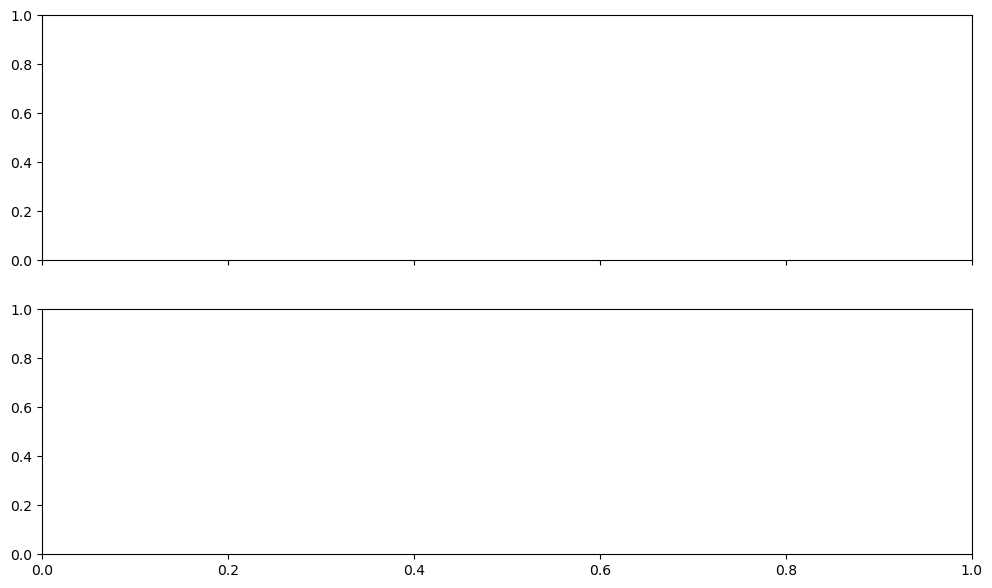

In [36]:
import numpy as np
import pandas as pd
import torch

@torch.no_grad()
def run_policy_through_env_realdata(env, model, device, deterministic=True):
    """
    Runs a fixed policy through your real-data PortfolioEnv and records:
      - net_ret (from info) for wealth curve
      - weights actually used by env mapping (BIL residual mechanism)
      - date

    Assumes:
      env.reset() -> state
      env.step(a) -> next_state_or_None, reward, done, info
      model(obs) -> (mu, log_std, v)  OR model.act(obs) exists (we'll use forward)
    """
    s = env.reset()
    done = False

    dates = []
    net_rets = []
    rewards = []
    W = []
    z_list = []

    while not done:
        s_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
        z = model.shared(s_t).squeeze(0).cpu().numpy()
        mu, log_std, v = model(s_t)
        mu = mu.squeeze(0)

        if deterministic:
            a = mu
        else:
            std = torch.exp(log_std)
            a = mu + std * torch.randn_like(mu)

        a_np = a.detach().cpu().numpy().astype(np.float32)

        # IMPORTANT: replicate the env's actual weight mapping (no env change needed)
        w = env._action_to_weights_with_BIL_residual(
            a_np, bil_idx=env.bil_idx, allow_short_risky=True
        )

        s2, r, done, info = env.step(a_np)

        # Use net_ret for wealth (reward is log_ret - penalty, not a return)
        net_rets.append(float(info["net_ret"]))
        rewards.append(float(r))
        dates.append(info["date"])
        W.append(w.astype(float))
        z_list.append(z)


        if s2 is None:
            break
        s = s2

    W = np.vstack(W) if len(W) else np.zeros((0, len(env.tickers)))
    out = pd.DataFrame(W, columns=[f"w_{tkr}" for tkr in env.tickers])
    out["net_ret"] = np.array(net_rets, dtype=float)
    out["reward"]  = np.array(rewards, dtype=float)
    out["wealth"]  = np.cumprod(1.0 + out["net_ret"].to_numpy())
    out["date"]    = dates
    out["z"] = z_list

    z_dim = out["z"].iloc[0].shape[0]
    Z = np.vstack(out["z"].values)
    for j in range(z_dim):
        out[f"z{j}"] = Z[:, j]
    out = out.drop(columns=["z"])

    return out

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# -----------------------------
# 1) Create figure once
# -----------------------------
fig, (ax_w, ax_pos) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plt.close(fig)
display(fig)

def redraw_plots_realdata(out, it, title_prefix=""):
    # X axis: use date if present, else index
    x = out["date"].to_numpy() if "date" in out.columns else np.arange(len(out))

    ax_w.clear()
    ax_pos.clear()

    wealth_last = float(out["wealth"].iloc[-1]) if len(out) else np.nan
    net_mean = float(out["net_ret"].mean()) if len(out) else np.nan

    ax_w.plot(x, out["wealth"].to_numpy())
    ax_w.set_title(f"{title_prefix}iter {it} | last wealth={wealth_last:.4f} | mean net_ret={net_mean:.4g}")
    ax_w.set_ylabel("wealth")

    # Weight columns are w_<TICKER>
    w_cols = [c for c in out.columns if c.startswith("w_")]

    for c in w_cols:
        ax_pos.plot(x, out[c].to_numpy(), label=c.replace("w_", ""))

    ax_pos.set_title("Weights through time")
    ax_pos.set_xlabel("date" if "date" in out.columns else "timestep")
    ax_pos.set_ylabel("weight")
    ax_pos.legend(ncol=4, fontsize=9)

    fig.tight_layout()
    clear_output(wait=True)
    display(fig)

# -----------------------------
# 2) Example hook inside training loop
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Choose which env you want to evaluate through (train_env / val_env / test_env)
eval_env = val_env  # <-- change as you like

# Inside your PPO loop, after each update:
# out = run_policy_through_env_realdata(eval_env, ac, device=device, deterministic=True)
# redraw_plots_realdata(out, it, title_prefix="VAL | ")



### Run training here to visualize live

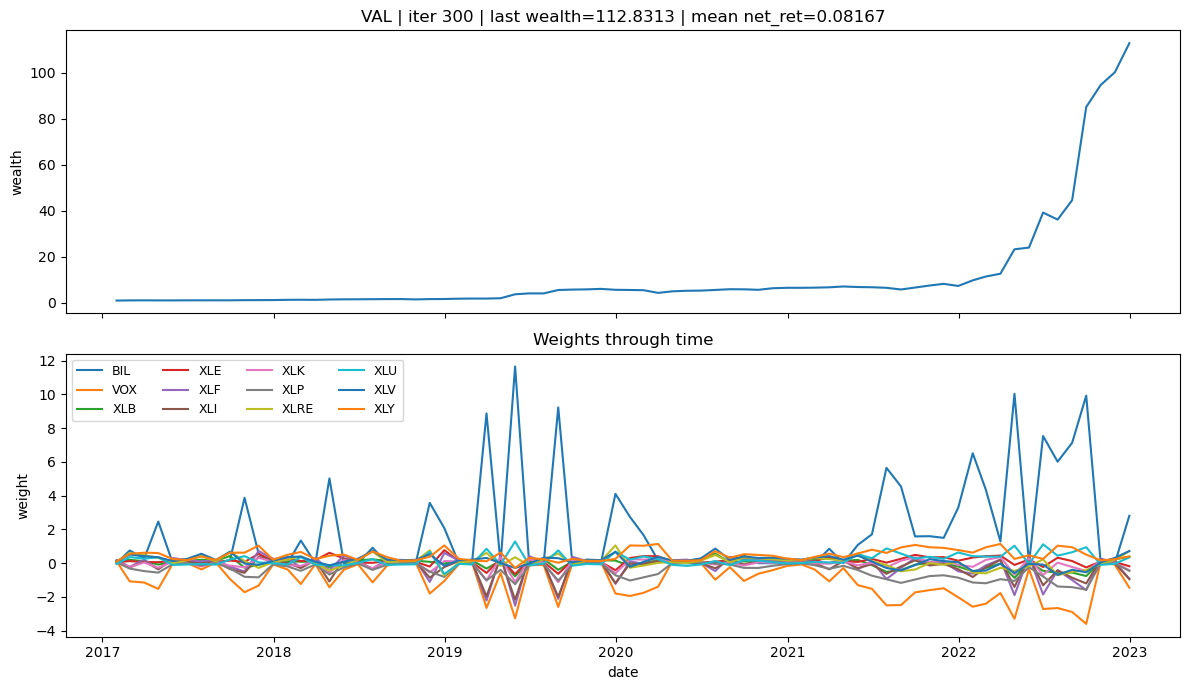

iter  300 | train_ep_reward 3.9514 | val_ep_reward 2.6772


In [37]:
n_iters = 300
train_ep_rewards = []
val_ep_rewards = []

for it in range(1, n_iters + 1):
    # --- train rollout + update ---
    roll = collect_rollout(train_env)
    train_ep_rewards.append(float(roll["rewards"].sum()))
    ppo_update(roll)

    # --- val rollout (same as before, for scalar metric) ---
    vroll = collect_rollout(train_env)
    val_ep_rewards.append(float(vroll["rewards"].sum()))

    out = run_policy_through_env_realdata(train_env, ac, device=device, deterministic=True)
    redraw_plots_realdata(out, it, title_prefix="VAL | ")


    # --- NEW: sequential deterministic eval + redraw plots every 20 iters ---
    if it % 20 == 0:
        print(
            f"iter {it:4d} | "
            f"train_ep_reward {train_ep_rewards[-1]:.4f} | "
            f"val_ep_reward {val_ep_rewards[-1]:.4f}"
        )

        

## Step 9: Training loop (+ quick validation)

Repeat:

1. Collect rollout on `train_env`
2. Update policy using PPO
3. Evaluate on `val_env` (no training)

Validation is used to:
- Monitor overfitting
- Tune hyperparameters

In [38]:
n_iters = 300
train_ep_rewards = []
val_ep_rewards = []

for it in range(1, n_iters + 1):
    roll = collect_rollout(train_env)
    train_ep_rewards.append(float(roll["rewards"].sum()))

    ppo_update(roll)

    vroll = collect_rollout(val_env)
    val_ep_rewards.append(float(vroll["rewards"].sum()))

    if it % 20 == 0:
        print(
            f"iter {it:4d} | "
            f"train_ep_reward {train_ep_rewards[-1]:.4f} | "
            f"val_ep_reward {val_ep_rewards[-1]:.4f}"
        )


iter   20 | train_ep_reward 3.6717 | val_ep_reward 0.0502
iter   40 | train_ep_reward 4.3130 | val_ep_reward 0.3621
iter   60 | train_ep_reward 3.9817 | val_ep_reward 0.1599
iter   80 | train_ep_reward 5.3436 | val_ep_reward 0.2660
iter  100 | train_ep_reward 3.2202 | val_ep_reward 0.1238
iter  120 | train_ep_reward 5.1445 | val_ep_reward -0.0261
iter  140 | train_ep_reward 5.5232 | val_ep_reward -0.0611
iter  160 | train_ep_reward 5.2161 | val_ep_reward 0.0213
iter  180 | train_ep_reward 4.9803 | val_ep_reward 0.1086
iter  200 | train_ep_reward 3.6172 | val_ep_reward 0.0521
iter  220 | train_ep_reward 6.5971 | val_ep_reward -0.1358
iter  240 | train_ep_reward 5.6730 | val_ep_reward 0.1118
iter  260 | train_ep_reward 5.9964 | val_ep_reward -0.5291
iter  280 | train_ep_reward 6.5235 | val_ep_reward 0.0239
iter  300 | train_ep_reward 5.4612 | val_ep_reward 0.0823


**Caveat**:
does the following plot training vs. validation rewards make sense?

**Look at Return instead of reward**

**Look at reward at each time step**

## Step 10: Plot Training vs Validation Rewards

check whether learning is happening

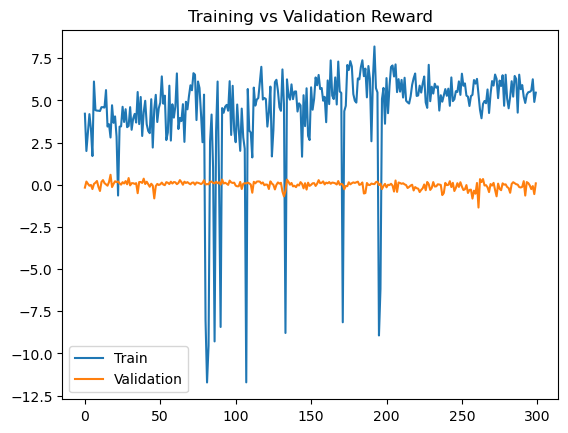

In [39]:
plt.plot(train_ep_rewards, label="Train")
plt.plot(val_ep_rewards, label="Validation")
plt.legend()
plt.title("Training vs Validation Reward")
plt.show()

Train reward trending upward

Validation reward not collapsing

There is divergence between train and val, recall our split:

Train: 2016–2022

Val: 2023

Test: 2024–2025

Markets in 2023 were structurally different from 2016–2021 (rate hikes, regime shift, dispersion changes, etc.). Such gap suggests generalization is limited and mild overfitting.

How to fix? Tune hyperparameters?

## Step 11: Test Set Evaluation and Backtest Construction

Freezing the trained model

Running rollout on test_env

Converting it into return series

Plotting cumulative return

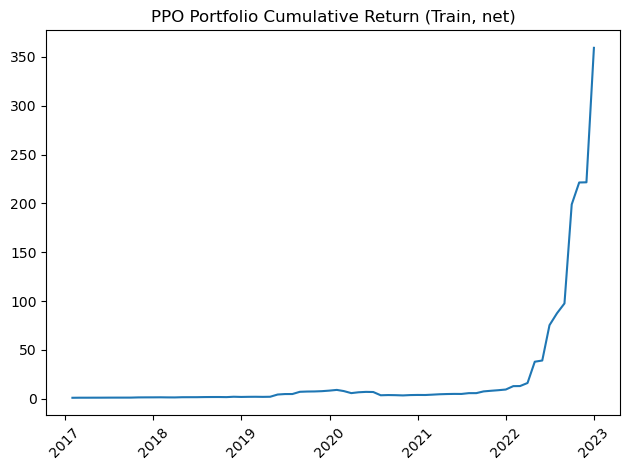

In [40]:
test_roll = collect_rollout(train_env)

test_infos = test_roll["infos"]
net_rets = np.array([info["net_ret"] for info in test_infos], dtype=float)
dates = [info["date"] for info in test_infos]

cum_ret = np.cumprod(1 + net_rets)

import matplotlib.pyplot as plt
plt.plot(dates, cum_ret)
plt.title("PPO Portfolio Cumulative Return (Train, net)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

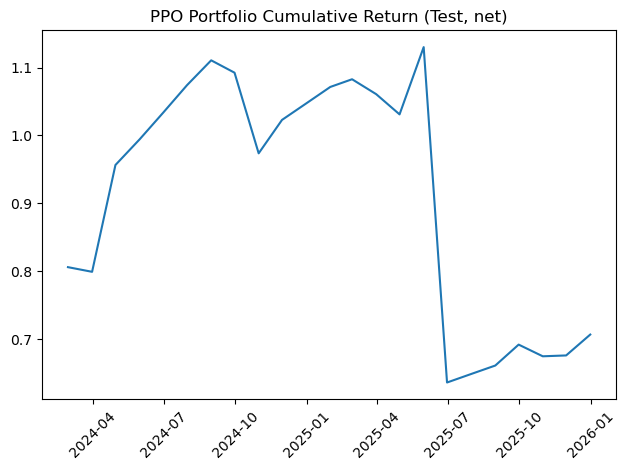

In [41]:
test_roll = collect_rollout(test_env)

test_infos = test_roll["infos"]
net_rets = np.array([info["net_ret"] for info in test_infos], dtype=float)
dates = [info["date"] for info in test_infos]

cum_ret = np.cumprod(1 + net_rets)

import matplotlib.pyplot as plt
plt.plot(dates, cum_ret)
plt.title("PPO Portfolio Cumulative Return (Test, net)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 12: Compute financial metrics for comparison (Sharpe Ratio, Max drawdown, Volatility...) 

In [42]:
def get_performance_metrics(returns, periods=12, rf=0):
    returns = np.asarray(returns)
    wealth = np.cumprod(1+returns)

    end_return = wealth[-1] - 1
    years = len(returns)/periods

    cagr = np.nan
    if years > 0:
        cagr = (wealth[-1] ** (1/years))-1
    
    peak = np.maximum.accumulate(wealth)
    max_drawdown = float(((wealth/peak) -1).min())

    annualized_vol = np.std(returns, ddof=1) * np.sqrt(periods)
    #highest vol regime observed
    vol = pd.Series(returns).rolling(6).std() * np.sqrt(12)
    max_rolling_vol = vol.max()

    sharpe = np.mean(returns)*(periods)/annualized_vol

    return wealth[-1], cagr, max_drawdown, annualized_vol, max_rolling_vol,sharpe

## Step 13: Convert Test Rollout Into Backtest Series

### Understanding how sensitive the performance is to action sampling:

In [87]:
def mc_test_policy_noise(env, model, device, num_sims=1000, seed=123):
    runs = []
    out_df = []
    for i in range(num_sims):
        seed = seed + i
        np.random.seed(seed)
        torch.manual_seed(seed)
        
        #need deterministic to be false so it samples differently
        out = run_policy_through_env_realdata(env, model, device=device, deterministic=False)
        out_df.append(out)
        returns = out["net_ret"].to_numpy()
        #QQQQ: do we take rf = 0? use the etf info? 
        end_wealth, cagr, mdd, ann_vol, rol_vol, sharpe = get_performance_metrics(returns, periods=12, rf=0)

        runs.append({
            "seed": seed,
            "simulation":i+1,
            "end_wealth": end_wealth,
            "cagr": float(cagr),
            "max_drawdown": float(mdd),
            "annualized_vol": float(ann_vol),
            "max_vol_rolling_6m": float(rol_vol),
            "sharpe": float(sharpe)
        })
    df = pd.DataFrame(runs)
    return df


def plot_metrics(mc_df, title="V1 Agent Perfomance Distribution v/s Benchmark Dashboard"):
    fig = plt.figure(figsize=(16,12))
    cols = mc_df.drop(columns=["simulation","seed"]).columns.to_list()
    benchmark = {
        "end_wealth": 1.2054414169691656,
        "cagr": 0.09792596151524058,
        "max_drawdown": -0.23166865769509815,
        "annualized_vol": 0.27278683845913476,
        "max_vol_rolling_6m": 0.5389250237567842,
        "sharpe": 0.47729462181507226
    }

    for i, col in enumerate(cols):
        ax = fig.add_subplot(3,3,i+1)
        ax.hist(mc_df[col].dropna(), bins=40)
        ax.set_title(f"{col} distribution")

        ax.axvline(
                benchmark[col],
                color="red",
                linestyle="--",
                linewidth=2,
                label="Benchmark"
            )
        ax.legend()


    ax6 = fig.add_subplot(3,3,7)
    ax6.scatter(mc_df["annualized_vol"], mc_df["cagr"], alpha=0.5)
    ax6.set_title("Vol vs CAGR")
    ax6.set_xlabel("Annualized Volatility")
    ax6.set_ylabel("CAGR")
    ax6.scatter(
        benchmark["annualized_vol"],
        benchmark["cagr"],
        color="red",
        s=120,
        zorder=5,
        label="Benchmark"
    )
    ax6.legend()

    ax7 = fig.add_subplot(3,3,8)
    ax7.scatter(mc_df["max_drawdown"], mc_df["cagr"], alpha=0.5)
    ax7.set_title("Max Drawdown vs CAGR")
    ax7.set_xlabel("Max Drawdown")
    ax7.set_ylabel("CAGR")
    ax7.scatter(
        benchmark["max_drawdown"],
        benchmark["cagr"],
        color="red",
        s=120,
        zorder=5,
        label="Benchmark"
    )
    ax7.legend()

    ax8 = fig.add_subplot(3,3,9)
    ax8.scatter(mc_df["max_vol_rolling_6m"], mc_df["cagr"], alpha=0.5)
    ax8.set_title("Max Vol (6m Rolling) vs CAGR")
    ax8.set_xlabel("Max Vol Rolling 6m")
    ax8.set_ylabel("CAGR")

    ax8.scatter(
        benchmark["max_vol_rolling_6m"],
        benchmark["cagr"],
        color="red",
        s=120,
        zorder=5,
        label="Benchmark"
    )
    ax8.legend()
    
    fig.suptitle(title, fontsize=20)
    fig.tight_layout()
    plt.show()



#got this code from chatgpt:
def plot_representative_paths(env, model, device, mc_df, base_seed=12345):
    # pick representative sims by CAGR
    best_i = int(mc_df["cagr"].idxmax())
    worst_i = int(mc_df["cagr"].idxmin())
    med_target = mc_df["cagr"].median()
    median_i = int((mc_df["cagr"] - med_target).abs().idxmin())

    picks = [("Best", best_i), ("Median", median_i), ("Worst", worst_i)]

    plt.figure(figsize=(12,5))
    for label, idx in picks:
        seed = int(mc_df.loc[idx, "seed"])
        np.random.seed(seed); torch.manual_seed(seed)
        out = run_policy_through_env_realdata(env, model, device=device, deterministic=False)
        plt.plot(out["date"], out["wealth"], label=f"{label} (seed={seed})")

    plt.title("Representative MC Wealth Paths")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


        


In [44]:
mc_df = mc_test_policy_noise(test_env, ac, device=device, num_sims=1000)
mc_df.iloc[:, 2:].describe(percentiles=[0.05, 0.5, 0.95])


,end_wealth,cagr,max_drawdown,annualized_vol,max_vol_rolling_6m,sharpe
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.628216,-0.236496,-0.544105,0.428982,0.676314,-0.403493
std,0.305417,0.189117,0.147742,0.098145,0.175371,0.503788
min,0.095640,-0.706127,-0.899257,0.149781,0.210155,-1.839174
5%,0.246360,-0.518543,-0.772659,0.277090,0.411165,-1.158244
50%,0.574508,-0.251114,-0.552215,0.426694,0.662545,-0.442090
95%,1.167688,0.084244,-0.282154,0.596363,0.982133,0.426749
max,2.493045,0.610607,-0.069417,0.766070,1.273216,2.115035


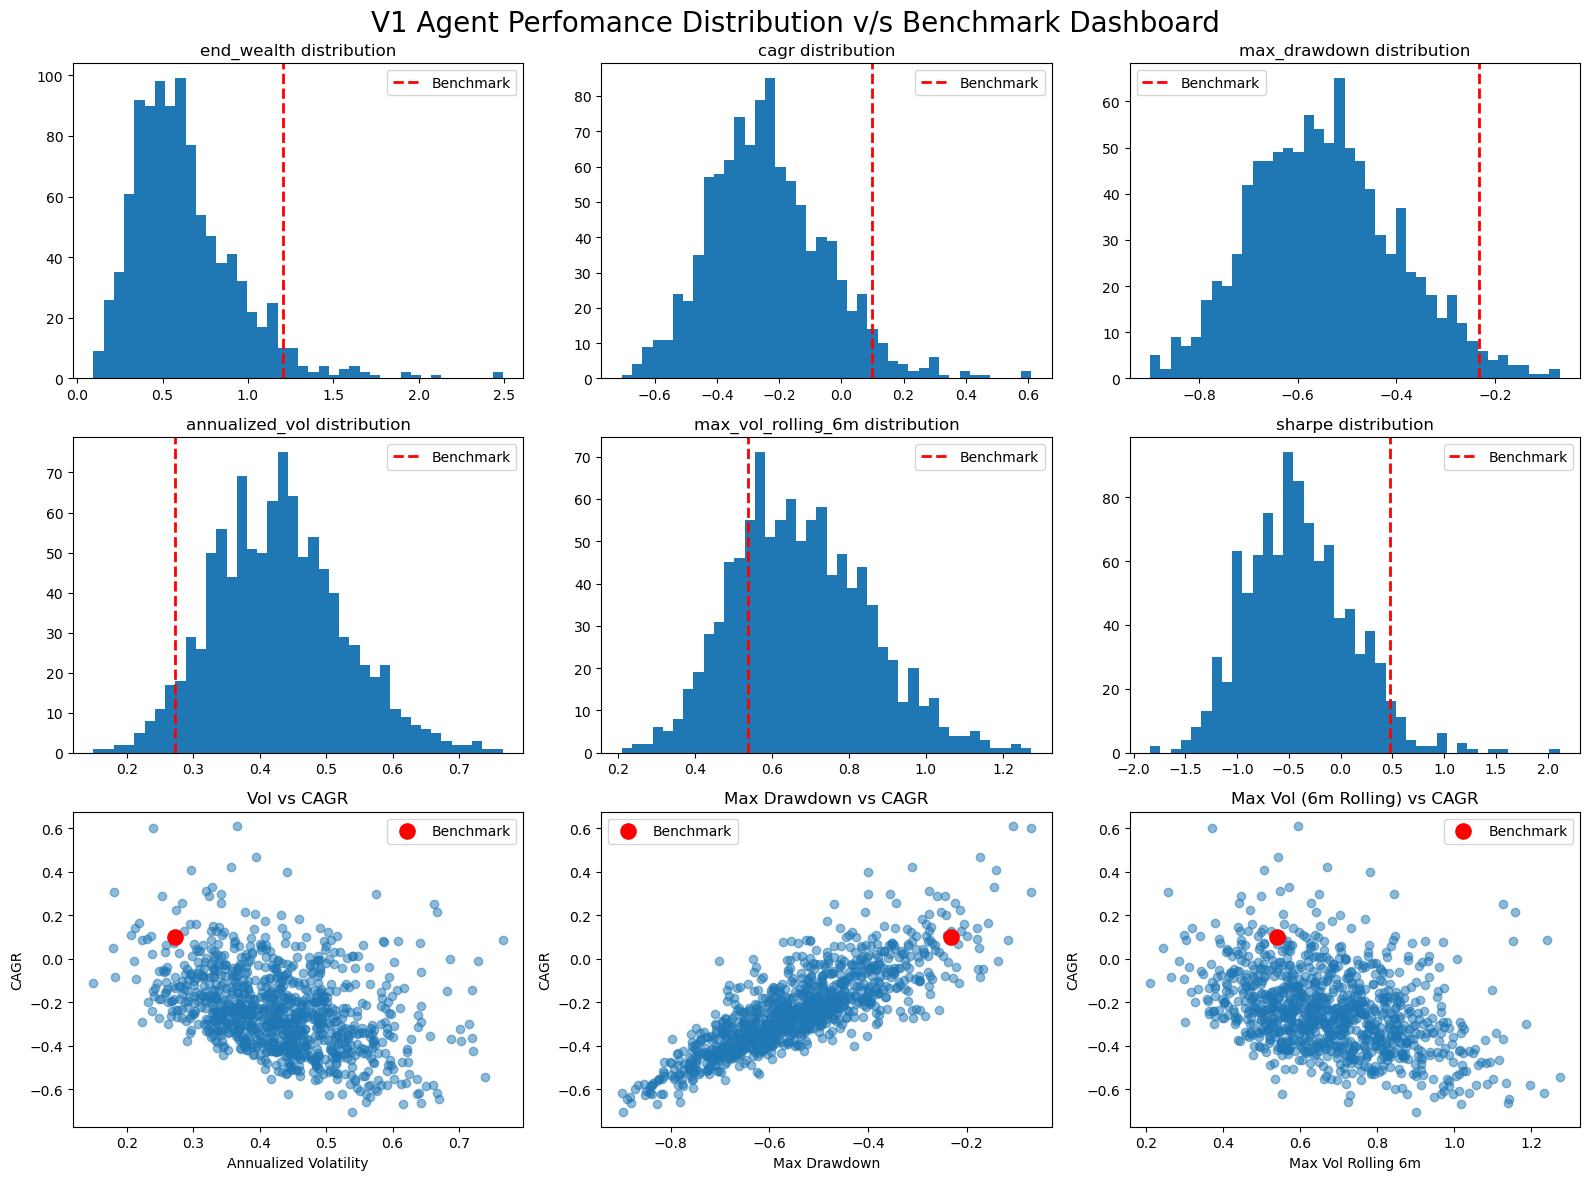

In [88]:
plot_metrics(mc_df)

Interpretations: 
- End wealth: Right skewed with a long right tail. Most outcomes cluster above 1x capital
- CAGR: centered around 20-35% but has a wide spread. While there is a strong upside potential, we can observe that the performance is sensitive to path/market regime
- Annualized Volatility: The volatility in returns is quite high which suggests rapid allocation shifts, and concentrated allocations
- Max drowdown: There is significant risk and shows that the RL is not risk aware/need to add a downside risk constraint
- Max Voltility regimes/Annualized VOlatility vs CAGR: Agent doesn't necessarily learn about over-risking without proportional return improvement(we are not maximizing sharpe in our reward so this aligns). 
- Max Drawdown vs CAGR: We can see that drawdown is inversely linked with long term groiwth --> suggests some kind of constraint over drawdowns

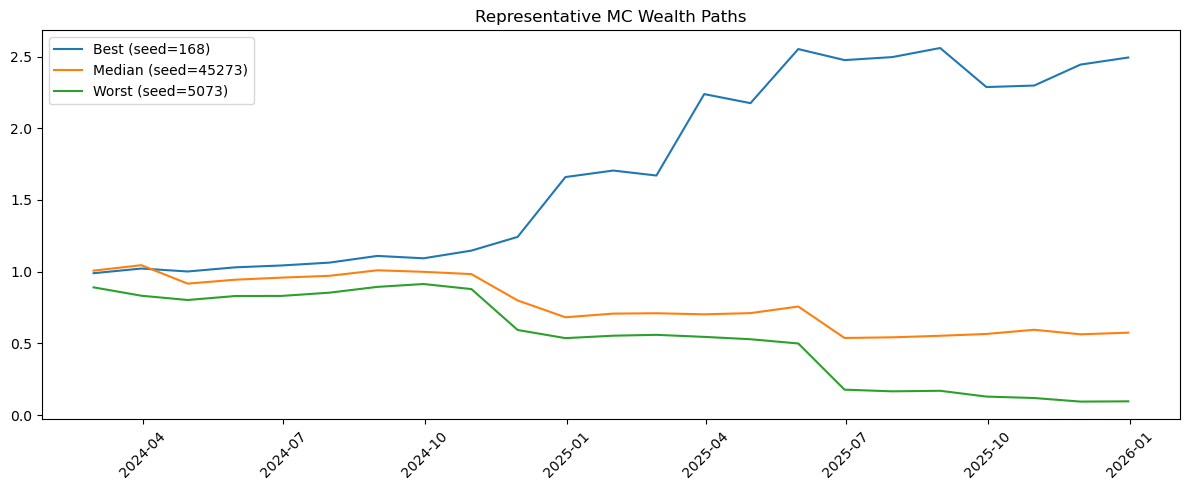

In [46]:
plot_representative_paths(test_env, ac, device, mc_df)

## Step 14: Compare Against Benchmark （Run Sequential Markowitz model over same test window）

## Step 15: Inspect Learned Behavior

For instance:

Does PPO allocate more to BIL during high VIX?

Does it rotate sectors during high dispersion?

Does it reduce risk during curve inversion?

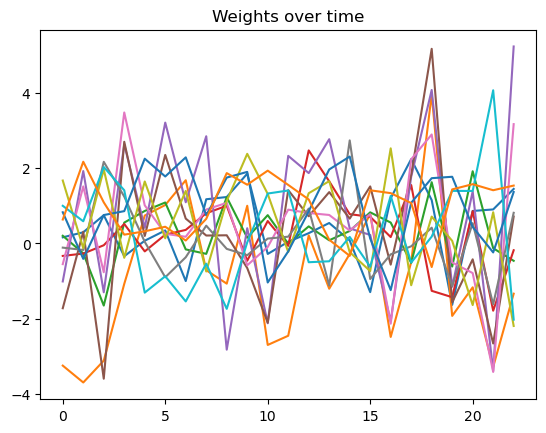

In [47]:
weights = np.array(test_roll["actions"])
plt.plot(weights)
plt.title("Weights over time")
plt.show()

### Regime analysis

In [48]:
etf_df.columns.to_list()

['ret_1m', 'vol_1m', 'amihud_1m', 'avg_corr_1m', 'xsec_disp_1m']

In [49]:
macro_df.columns

Index(['CPI', 'INDPRO', 'TERM_SPREAD', 'FED_RATE', 'HY_OAS', 'VIX', 'CPI_q',
       'INDPRO_q', 'TERM_SPREAD_m', 'FED_RATE_m', 'HY_OAS_m', 'VIX_m', 'CPI_z',
       'INDPRO_z', 'TERM_SPREAD_z', 'FED_RATE_z', 'HY_OAS_z', 'VIX_z',
       'CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z',
       'HY_OAS_m_z', 'VIX_m_z', 'curve_inv', 'high_vol', 'credit_spread'],
      dtype='object')

In [50]:
#separating asset level info from date level info and transforming asset level to date level. 
asset_cols = ['ret_1m', 'vol_1m']
date_cols = ['avg_corr_1m', 'xsec_disp_1m', 'CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z',
       'HY_OAS_m_z', 'VIX_m_z', 'curve_inv', 'high_vol', 'credit_spread']

asset_mean = panel[asset_cols].groupby(level=0).mean().add_suffix("_mean")
print(f"asset mean shape : {asset_mean.shape}")
asset_std = panel[asset_cols].groupby(level=0).std().add_suffix("_std")
print(f"asset std shape : {asset_std.shape}")
date_level = panel[date_cols].groupby(level=0).first()
print(f"date level shape : {date_level.shape}")

df = pd.concat([asset_mean, asset_std, date_level], axis=1).dropna()
print(df.shape)




asset mean shape : (109, 2)
asset std shape : (109, 2)
date level shape : (109, 11)
(109, 15)


In [51]:
df.head()

,ret_1m_mean,vol_1m_mean,ret_1m_std,vol_1m_std,avg_corr_1m,xsec_disp_1m,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
date,,,,,,,,,,,,,,,
2016-12-31,0.023915,0.006860,0.023661,0.002463,0.454200,0.023549,0.645725,1.189782,2.795910,1.038643,-1.018538,-1.016227,0,0,0
2017-01-31,0.013975,0.006434,0.021617,0.002677,0.262937,0.022227,0.993252,0.790520,-0.053161,0.489363,0.016223,-0.124984,0,0,0
2017-02-28,0.026933,0.005330,0.030849,0.002501,0.220065,0.031155,1.078891,0.743678,0.013558,-0.349651,-1.582065,-0.655788,0,0,0
2017-03-31,-0.003701,0.006507,0.015302,0.003037,0.453315,0.016006,0.206501,0.648779,-0.590274,0.420665,-0.950084,0.146048,0,0,0
2017-04-30,0.008050,0.005625,0.015325,0.002480,0.384578,0.015891,-0.542625,2.218795,-0.087853,0.155158,0.064685,-0.103543,0,0,0


In [52]:
train_mask = (df.index <= "2022-12-31")

scaler = StandardScaler().fit(df.loc[train_mask].values)
df_scaled = scaler.transform(df)

K = 4
hmm = GaussianHMM(n_components=K, covariance_type="diag", n_iter=500, random_state=0)
hmm.fit(df_scaled[train_mask])

mkt_regime = pd.Series(hmm.predict(df_scaled), index=df.index, name="mkt_regime")

In [53]:
df_scaled.shape

(109, 15)

In [54]:
mkt_regime.to_csv("market_regime.csv")

In [55]:
mkt_regime.value_counts()

mkt_regime
2    37
3    32
0    27
1    13
Name: count, dtype: int64

In [56]:
summary = df.join(mkt_regime).groupby("mkt_regime").mean()
summary


,ret_1m_mean,vol_1m_mean,ret_1m_std,vol_1m_std,avg_corr_1m,xsec_disp_1m,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
mkt_regime,,,,,,,,,,,,,,,
0,-0.002160,0.012314,0.038800,0.005112,0.593799,0.036816,-0.692508,-0.505008,0.056804,-0.261855,0.117481,0.016198,0.592593,0.000000,0.111111
1,0.007285,0.015628,0.041835,0.006118,0.487746,0.041098,-0.437432,-0.056787,0.139420,-0.855034,0.466706,0.242893,0.846154,0.615385,0.076923
2,0.015926,0.006887,0.024435,0.002795,0.346084,0.024556,-0.087704,0.144979,-0.373375,-0.509202,-0.102882,-0.226378,0.324324,0.000000,0.189189
3,0.013437,0.011294,0.037436,0.005119,0.504663,0.037394,0.654352,0.183194,-0.032382,0.211762,-0.039064,0.095112,0.000000,0.343750,0.062500


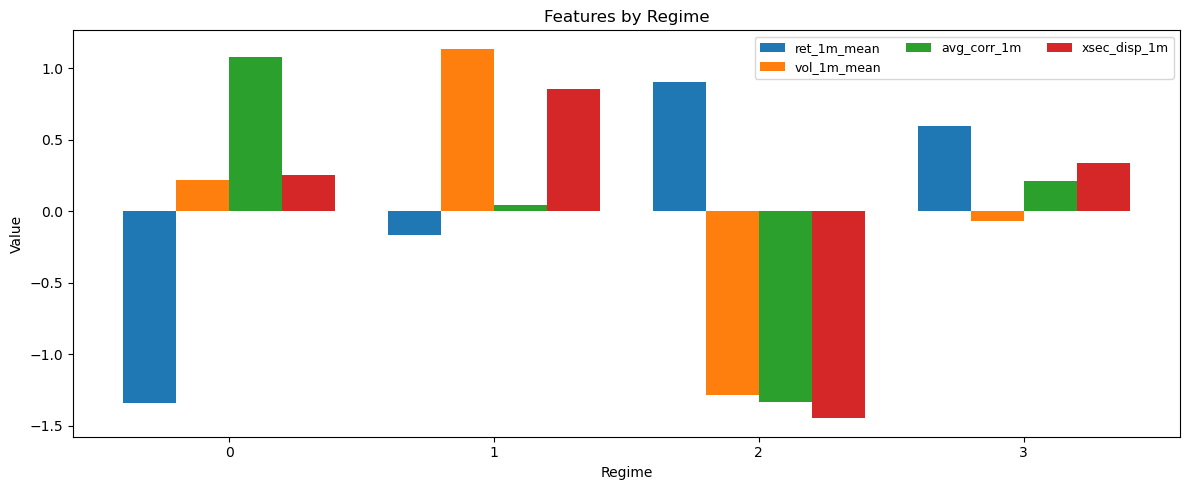

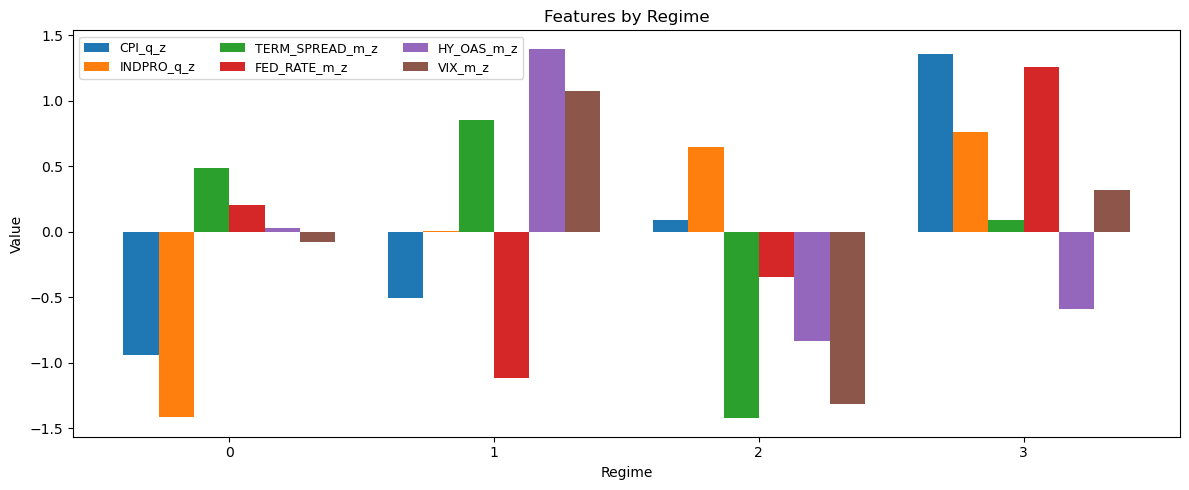

In [57]:


visuals = [
    ['ret_1m_mean', 'vol_1m_mean', 'avg_corr_1m', 'xsec_disp_1m'],
    ['CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z', 'HY_OAS_m_z', 'VIX_m_z']
    
]
summary = (summary-summary.mean())/summary.std()
for cols in visuals:
    regimes = summary.index
    n_regimes = len(regimes)
    n_vars = len(cols)

    x = np.arange(n_regimes)

    # choose width based on how many bars you have
    width = 0.8 / n_vars   # total group width ~0.8

    plt.figure(figsize=(12,5))

    for i, col in enumerate(cols):
        plt.bar(x + i*width, summary[col].values, width=width, label=col)

    # center tick labels under the group
    plt.xticks(x + width*(n_vars-1)/2, regimes)

    plt.xlabel("Regime")
    plt.ylabel("Value")
    plt.title("Features by Regime")
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


In [58]:
# look at dates, weights of regime 0 and the drawdown in regime 0 

Can interpret this as follows:
- Regime 0 — Growth Scare / Early Slowdown
    - Below-average market returns
    - Slightly elevated volatility
    - High cross-asset correlation
    - Weak CPI and industrial production
    ---> not full crisis, but macro deterioration phase( no severe credit stress)
- Regime 1 — Monetary Tightening / Credit Stress
    - Slightly negative returns
    - Elevated volatility and dispersion
    - High credit spreads (HY_OAS ↑)
    - Curve inversion present
    - Elevated VIX
     --> Clear rate-hike / financial tightening environment

- Regime 2 — Recovery regime
    - Strong positive returns
    - Low volatility
    - Low correlation and dispersion
    - Low credit stress
    - Improving macro backdrop
    --> Classic expansion / recovery regime

- Regime 3 — Inflationary / Late-Cycle
    - Positive but more uneven returns
    - Higher inflation (CPI ↑)
    - Rising Fed rates
    - Moderate volatility
    - Correlation picking up
    --> Late-cycle or inflation-driven environment




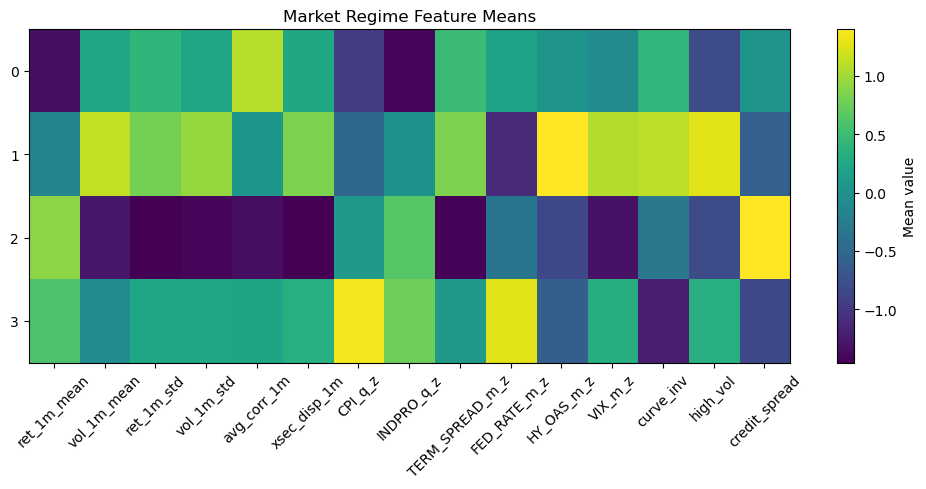

In [59]:
cols = summary.columns.to_list()
data = summary

plt.figure(figsize=(10,5))
plt.imshow(data.values, aspect="auto")
plt.colorbar(label="Mean value")

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(data.index)), data.index)

plt.title("Market Regime Feature Means")
plt.tight_layout()
plt.show()

### Analyzing performance per regime

In [60]:
df.head()

,ret_1m_mean,vol_1m_mean,ret_1m_std,vol_1m_std,avg_corr_1m,xsec_disp_1m,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
date,,,,,,,,,,,,,,,
2016-12-31,0.023915,0.006860,0.023661,0.002463,0.454200,0.023549,0.645725,1.189782,2.795910,1.038643,-1.018538,-1.016227,0,0,0
2017-01-31,0.013975,0.006434,0.021617,0.002677,0.262937,0.022227,0.993252,0.790520,-0.053161,0.489363,0.016223,-0.124984,0,0,0
2017-02-28,0.026933,0.005330,0.030849,0.002501,0.220065,0.031155,1.078891,0.743678,0.013558,-0.349651,-1.582065,-0.655788,0,0,0
2017-03-31,-0.003701,0.006507,0.015302,0.003037,0.453315,0.016006,0.206501,0.648779,-0.590274,0.420665,-0.950084,0.146048,0,0,0
2017-04-30,0.008050,0.005625,0.015325,0.002480,0.384578,0.015891,-0.542625,2.218795,-0.087853,0.155158,0.064685,-0.103543,0,0,0


In [61]:
n_sims = 1000
base_seed = 123

runs = []

for i in range(n_sims):
    seed = base_seed + i
    np.random.seed(seed)
    torch.manual_seed(seed)

    out = run_policy_through_env_realdata(complete_env, ac, device=device, deterministic=False)

    # index by date
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date")

    # keep only what you want to average
    runs.append(out)

# stack all sims then average by date
mc_all = pd.concat(runs)                      # index = date (repeats 1000 times)
out = mc_all.groupby(level=0).mean()     # one row per date

out.head()

,w_BIL,w_VOX,w_XLB,w_XLE,w_XLF,w_XLI,w_XLK,w_XLP,w_XLRE,w_XLU,...,z54,z55,z56,z57,z58,z59,z60,z61,z62,z63
date,,,,,,,,,,,,,,,,,,,,,
2017-01-31,0.000000,0.068204,0.075334,0.005674,0.228642,0.191289,0.144885,0.080428,0.062355,-0.041744,...,-0.382357,0.899386,-0.722117,0.143873,0.525562,-0.746860,0.859896,-0.688789,-0.637271,0.896827
2017-02-28,0.497866,-1.185862,0.075662,0.129970,0.067411,-0.091407,-0.206262,-0.007360,0.422274,0.561582,...,-0.653661,0.023177,0.282511,-0.096606,-0.313495,0.159325,-0.041493,-0.618097,0.122784,0.116856
2017-03-31,0.237472,-0.754029,-0.009563,0.005939,0.241675,0.051662,0.001043,0.042779,0.343594,0.425610,...,-0.712496,0.337774,0.238620,0.347154,-0.253638,0.098283,0.214863,-0.771280,0.158165,0.366132
2017-04-30,1.374596,-1.799499,0.008008,0.129344,-0.204017,-0.389355,-0.507993,-0.086297,0.666553,0.982289,...,-0.678571,-0.038764,0.365028,0.022294,-0.440774,0.260393,-0.085858,-0.663181,0.296644,0.002518
2017-05-31,0.005767,-0.063565,0.036058,0.032070,0.303995,0.177793,0.174022,0.061309,0.028340,-0.028360,...,-0.367003,0.684178,-0.605568,0.220822,0.161202,-0.247878,0.667599,-0.664091,-0.663097,0.748691


In [62]:
out.columns.to_list()

['w_BIL',
 'w_VOX',
 'w_XLB',
 'w_XLE',
 'w_XLF',
 'w_XLI',
 'w_XLK',
 'w_XLP',
 'w_XLRE',
 'w_XLU',
 'w_XLV',
 'w_XLY',
 'net_ret',
 'reward',
 'wealth',
 'z0',
 'z1',
 'z2',
 'z3',
 'z4',
 'z5',
 'z6',
 'z7',
 'z8',
 'z9',
 'z10',
 'z11',
 'z12',
 'z13',
 'z14',
 'z15',
 'z16',
 'z17',
 'z18',
 'z19',
 'z20',
 'z21',
 'z22',
 'z23',
 'z24',
 'z25',
 'z26',
 'z27',
 'z28',
 'z29',
 'z30',
 'z31',
 'z32',
 'z33',
 'z34',
 'z35',
 'z36',
 'z37',
 'z38',
 'z39',
 'z40',
 'z41',
 'z42',
 'z43',
 'z44',
 'z45',
 'z46',
 'z47',
 'z48',
 'z49',
 'z50',
 'z51',
 'z52',
 'z53',
 'z54',
 'z55',
 'z56',
 'z57',
 'z58',
 'z59',
 'z60',
 'z61',
 'z62',
 'z63']

In [63]:
out.shape

(108, 79)

In [64]:
cols = ['w_BIL',
 'w_VOX',
 'w_XLB',
 'w_XLE',
 'w_XLF',
 'w_XLI',
 'w_XLK',
 'w_XLP',
 'w_XLRE',
 'w_XLU',
 'w_XLV',
 'w_XLY']
X = out[cols]
test = X.join(mkt_regime, how="left")


In [65]:
test = test[test["mkt_regime"] == 0]

In [66]:
test

,w_BIL,w_VOX,w_XLB,w_XLE,w_XLF,w_XLI,w_XLK,w_XLP,w_XLRE,w_XLU,w_XLV,w_XLY,mkt_regime
date,,,,,,,,,,,,,
2018-12-31,0.275090,-0.732451,-0.017229,0.396811,0.598053,-0.120686,0.441950,-0.079379,-0.397960,-0.108918,-0.044763,0.789483,0
2019-01-31,0.022466,-0.176120,0.089268,0.094636,0.224301,0.112377,0.097106,0.035116,0.086566,0.041689,0.158215,0.214378,0
2019-05-31,11.453952,-5.034027,-0.520755,0.410347,-3.061054,-2.918471,-2.694563,-1.023855,1.196883,2.815837,-0.475412,0.851120,0
2019-08-31,11.197304,-4.334869,-0.403063,0.123012,-3.039714,-2.782733,-2.687682,-1.053280,1.264520,2.518443,-0.443918,0.641980,0
2020-02-29,1.051931,-1.894879,-0.076264,0.443144,0.024683,-0.416875,-0.124070,-0.116268,0.102927,0.899184,0.152667,0.953822,0
2022-04-30,10.215371,-4.626986,-0.675056,0.546476,-2.540454,-2.698226,-1.965362,-0.519433,0.185440,2.454807,-0.616061,1.239485,0
2022-05-31,0.033306,-0.279898,0.010505,0.103971,0.411711,0.117820,0.347600,0.102879,-0.165441,-0.041895,0.062357,0.297084,0
2022-06-30,9.592505,-4.235789,-0.539507,0.250142,-2.660037,-2.357481,-2.103256,-0.517814,0.633209,2.479524,-0.443516,0.902020,0
2022-07-31,1.601816,-2.230852,-0.207489,0.819702,0.493151,-0.789560,0.614903,-0.113113,-0.850924,0.385157,-0.360759,1.637969,0


In [67]:
regime_cols = df[["ret_1m_mean","curve_inv","VIX_m_z","HY_OAS_m_z","credit_spread","CPI_q_z"]]
out_regime = out[['net_ret', 'reward', 'wealth']]
regime_perf_df = out.join(mkt_regime, how="left")
regime_perf_df = regime_perf_df.join(regime_cols, how="left")
cols = ['net_ret', 'reward', 'wealth',
        'mkt_regime', 'ret_1m_mean', 'curve_inv', 'VIX_m_z',
       'HY_OAS_m_z', 'credit_spread', 'CPI_q_z']
regime_perf_df = regime_perf_df[cols]
regime_perf_df.head()

,net_ret,reward,wealth,mkt_regime,ret_1m_mean,curve_inv,VIX_m_z,HY_OAS_m_z,credit_spread,CPI_q_z
date,,,,,,,,,,
2017-01-31,0.018795,0.018609,1.018795,2,0.013975,0,-0.124984,0.016223,0,0.993252
2017-02-28,0.098154,0.091624,1.118788,2,0.026933,0,-0.655788,-1.582065,0,1.078891
2017-03-31,0.006588,0.006171,1.126450,2,-0.003701,0,0.146048,-0.950084,0,0.206501
2017-04-30,-0.033933,-0.035757,1.088181,2,0.008050,0,-0.103543,0.064685,0,-0.542625
2017-05-31,0.010392,0.010273,1.099448,2,0.006076,0,-0.770055,0.709060,0,-1.112679


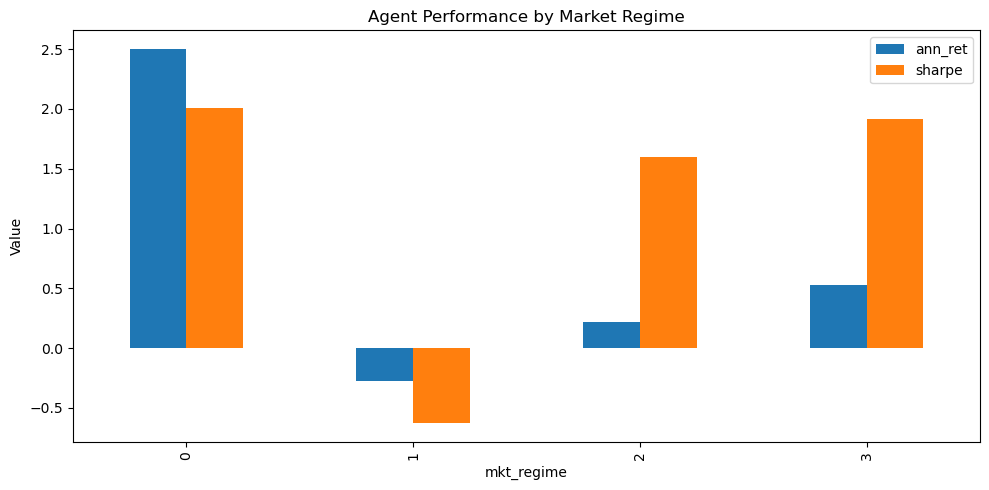

In [68]:
def perf_stats(x):
    ann_ret = np.mean(x) * 12
    ann_vol = np.std(x, ddof=1) * np.sqrt(12)
    sharpe = ann_ret / (ann_vol + 1e-12)
    return pd.Series({
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe
    })

perf_by_regime = regime_perf_df.groupby("mkt_regime")["net_ret"].apply(perf_stats)
perf_plot = perf_by_regime.unstack()

perf_plot[["ann_ret", "sharpe"]].plot(kind="bar", figsize=(10,5))
plt.title("Agent Performance by Market Regime")
plt.ylabel("Value")
plt.tight_layout()
plt.show()



In [69]:
(regime_perf_df["net_ret"] < 0).sum()

35

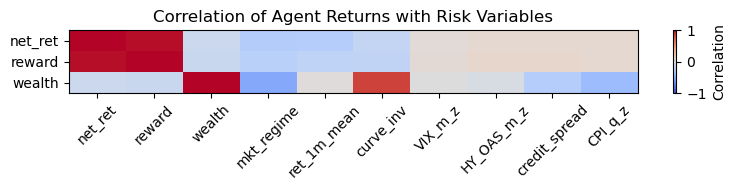

In [70]:
corr_matrix = regime_perf_df.corr()
corr_row = corr_matrix.loc[["net_ret", "reward", "wealth"]]

plt.figure(figsize=(8,2))
plt.imshow(corr_row.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_row.columns)), corr_row.columns, rotation=45)
plt.yticks([0,1,2], ["net_ret", "reward", "wealth"])

plt.title("Correlation of Agent Returns with Risk Variables")
plt.tight_layout()
plt.show()



### Policy based regime analysis

In [71]:

z_cols = [c for c in out.columns if c.startswith("z")]

Z = out[z_cols].values
Zs = StandardScaler().fit_transform(Z)

K_agent = 4
hmm_agent = GaussianHMM(n_components=K_agent, covariance_type="diag", n_iter=500, random_state=0)
hmm_agent.fit(Zs)

agent_regime = pd.Series(hmm_agent.predict(Zs), index=out.index, name="agent_regime")
agent_regime.value_counts()


agent_regime
2    46
3    34
1    15
0    13
Name: count, dtype: int64

In [72]:
out

,w_BIL,w_VOX,w_XLB,w_XLE,w_XLF,w_XLI,w_XLK,w_XLP,w_XLRE,w_XLU,...,z54,z55,z56,z57,z58,z59,z60,z61,z62,z63
date,,,,,,,,,,,,,,,,,,,,,
2017-01-31,0.000000,0.068204,0.075334,0.005674,0.228642,0.191289,0.144885,0.080428,0.062355,-0.041744,...,-0.382357,0.899386,-0.722117,0.143873,0.525562,-0.746860,0.859896,-0.688789,-0.637271,0.896827
2017-02-28,0.497866,-1.185862,0.075662,0.129970,0.067411,-0.091407,-0.206262,-0.007360,0.422274,0.561582,...,-0.653661,0.023177,0.282511,-0.096606,-0.313495,0.159325,-0.041493,-0.618097,0.122784,0.116856
2017-03-31,0.237472,-0.754029,-0.009563,0.005939,0.241675,0.051662,0.001043,0.042779,0.343594,0.425610,...,-0.712496,0.337774,0.238620,0.347154,-0.253638,0.098283,0.214863,-0.771280,0.158165,0.366132
2017-04-30,1.374596,-1.799499,0.008008,0.129344,-0.204017,-0.389355,-0.507993,-0.086297,0.666553,0.982289,...,-0.678571,-0.038764,0.365028,0.022294,-0.440774,0.260393,-0.085858,-0.663181,0.296644,0.002518
2017-05-31,0.005767,-0.063565,0.036058,0.032070,0.303995,0.177793,0.174022,0.061309,0.028340,-0.028360,...,-0.367003,0.684178,-0.605568,0.220822,0.161202,-0.247878,0.667599,-0.664091,-0.663097,0.748691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,0.000000,0.167750,0.085439,-0.033248,0.204409,0.200657,0.146103,0.096085,0.077245,-0.064159,...,-0.192573,0.936591,-0.720053,0.209427,0.594388,-0.879857,0.887305,-0.640666,-0.478678,0.901905
2025-09-30,3.277982,-1.844958,0.029802,0.340705,-0.643148,-1.023830,-0.724785,-0.230235,0.316266,0.833485,...,-0.283243,-0.427654,0.278961,-0.311430,-0.433008,0.250290,-0.417461,-0.232543,0.198461,-0.091744
2025-10-31,0.241466,-0.536297,-0.004797,0.015029,0.334836,0.050818,0.235857,0.045418,0.072349,0.183576,...,-0.426105,0.277765,-0.167935,0.429841,-0.126531,0.102363,0.310064,-0.792765,-0.162884,0.592173


In [73]:
agent_regime

date
2017-01-31    2
2017-02-28    3
2017-03-31    3
2017-04-30    3
2017-05-31    2
             ..
2025-08-31    2
2025-09-30    1
2025-10-31    2
2025-11-30    1
2025-12-31    0
Name: agent_regime, Length: 108, dtype: int64

In [74]:
Z.shape

(108, 64)

In [75]:
out.shape

(108, 79)

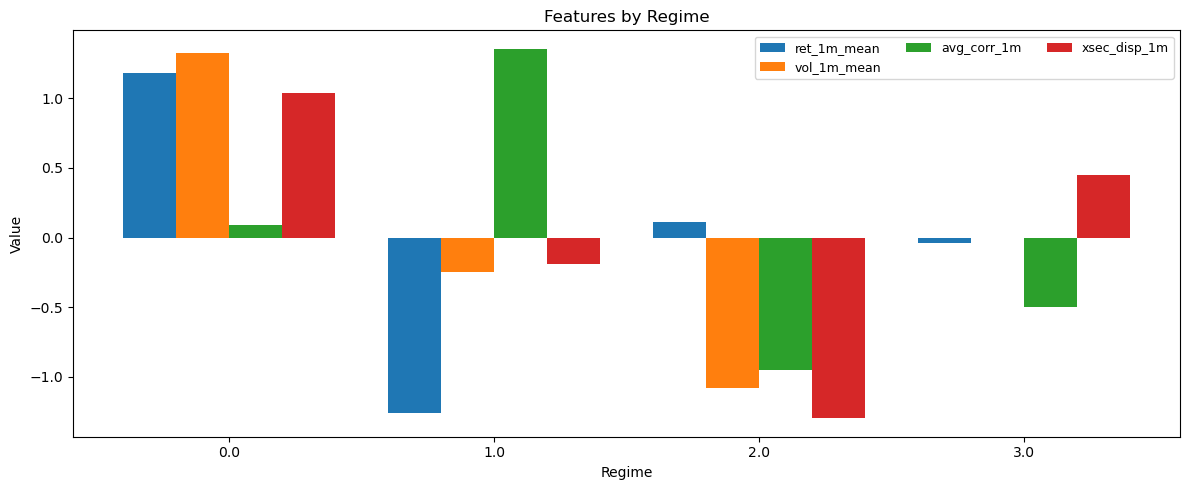

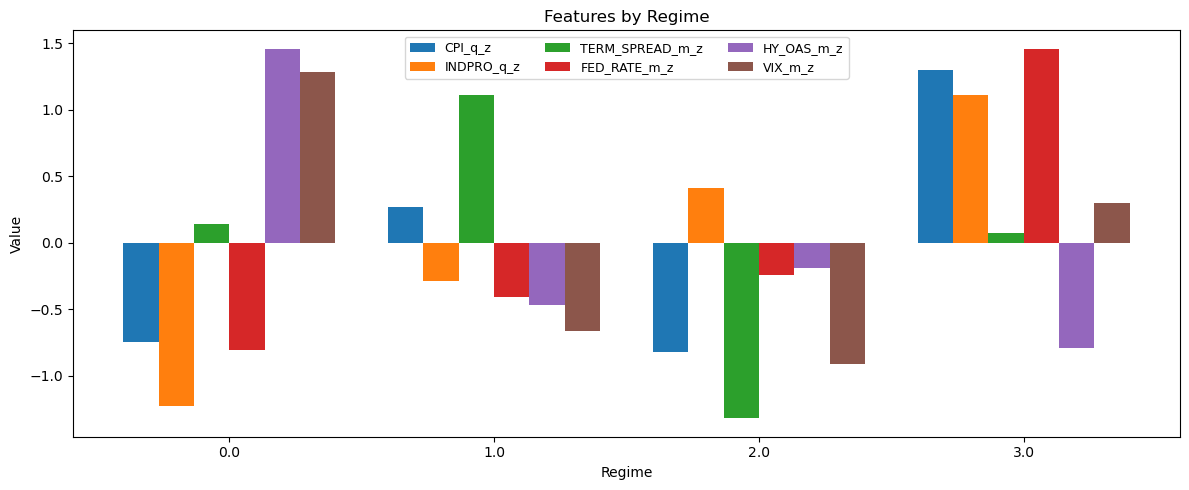

In [76]:
summary = df.join(agent_regime).groupby("agent_regime").mean()
summary




visuals = [
    ['ret_1m_mean', 'vol_1m_mean', 'avg_corr_1m', 'xsec_disp_1m'],
    ['CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z', 'HY_OAS_m_z', 'VIX_m_z']
    
]
summary = (summary-summary.mean())/summary.std()
for cols in visuals:
    regimes = summary.index
    n_regimes = len(regimes)
    n_vars = len(cols)

    x = np.arange(n_regimes)

    # choose width based on how many bars you have
    width = 0.8 / n_vars   # total group width ~0.8

    plt.figure(figsize=(12,5))

    for i, col in enumerate(cols):
        plt.bar(x + i*width, summary[col].values, width=width, label=col)

    # center tick labels under the group
    plt.xticks(x + width*(n_vars-1)/2, regimes)

    plt.xlabel("Regime")
    plt.ylabel("Value")
    plt.title("Features by Regime")
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


check where agent is learning the regime - interm output vs end output 

In [77]:
regime_cols = df[["ret_1m_mean","curve_inv","VIX_m_z","HY_OAS_m_z","credit_spread","CPI_q_z"]]
out_regime = out[['net_ret', 'reward', 'wealth']]
agent_regime_perf_df = out.join(agent_regime, how="left")
agent_regime_perf_df = agent_regime_perf_df.join(regime_cols, how="left")
cols = ['net_ret', 'reward', 'wealth',
        'agent_regime', 'ret_1m_mean', 'curve_inv', 'VIX_m_z',
       'HY_OAS_m_z', 'credit_spread', 'CPI_q_z']
agent_regime_perf_df = agent_regime_perf_df[cols]
agent_regime_perf_df.head()

,net_ret,reward,wealth,agent_regime,ret_1m_mean,curve_inv,VIX_m_z,HY_OAS_m_z,credit_spread,CPI_q_z
date,,,,,,,,,,
2017-01-31,0.018795,0.018609,1.018795,2,0.013975,0,-0.124984,0.016223,0,0.993252
2017-02-28,0.098154,0.091624,1.118788,3,0.026933,0,-0.655788,-1.582065,0,1.078891
2017-03-31,0.006588,0.006171,1.126450,3,-0.003701,0,0.146048,-0.950084,0,0.206501
2017-04-30,-0.033933,-0.035757,1.088181,3,0.008050,0,-0.103543,0.064685,0,-0.542625
2017-05-31,0.010392,0.010273,1.099448,2,0.006076,0,-0.770055,0.709060,0,-1.112679


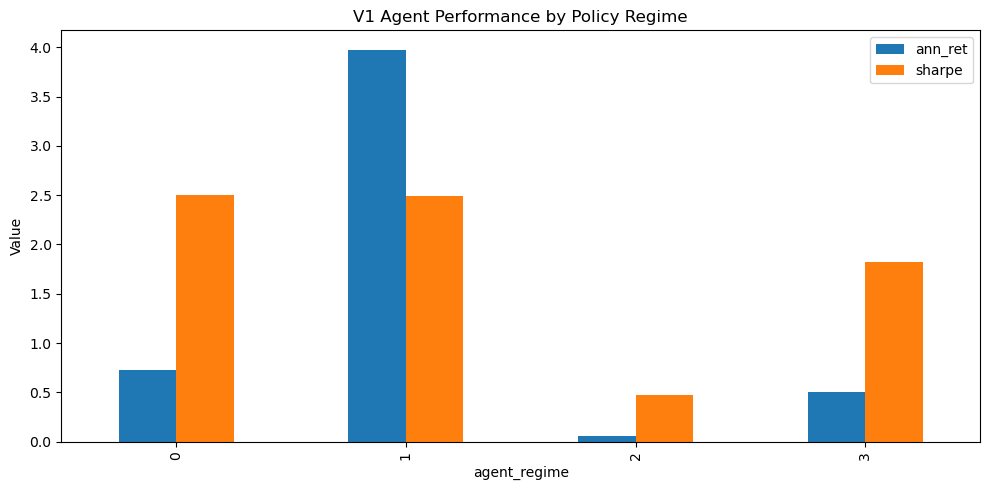

In [84]:
perf_by_agent_regime = agent_regime_perf_df.groupby("agent_regime")["net_ret"].apply(perf_stats)
perf_plot = perf_by_agent_regime.unstack()

perf_plot[["ann_ret", "sharpe"]].plot(kind="bar", figsize=(10,5))
plt.title("V1 Agent Performance by Policy Regime")
plt.ylabel("Value")
plt.tight_layout()
plt.show()
